# load things for science :)

In [4]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import matplotlib.pyplot
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.cm
import math
import sys
import csv
import itertools
from scipy import integrate
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path
# from tqdm import tqdm
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
# import ipywidgets as widgets
# from ipywidgets import FloatSlider, Layout, HBox, VBox, Label, Output, Button, IntProgress, HTML
from IPython.display import display, clear_output
# %matplotlib widget

# PID comparison

In [ ]:
df = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_2rec_excl_sp19inb_45nA_local_05_08_2026.csv", index_col=False)

# df.head()

# Force PID columns to integers
pid_cols = [
    "pid_prot_rec", "pid_prot_mc",
    "pid_pip_rec",  "pid_pip_mc",
    "pid_pim_rec",  "pid_pim_mc"
]

for col in pid_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype(int)

# Mismatch flags
df["prot_mismatch"] = df["pid_prot_mc"] != df["pid_prot_rec"]
df["pip_mismatch"]  = df["pid_pip_mc"]  != df["pid_pip_rec"]
df["pim_mismatch"]  = df["pid_pim_mc"]  != df["pid_pim_rec"]

# Counts
print("Total events:", len(df))
print()

print("Proton mismatches:", df["prot_mismatch"].sum())
print("Pi+ mismatches:   ", df["pip_mismatch"].sum())
print("Pi- mismatches:   ", df["pim_mismatch"].sum())

# Show problematic rows
print("\nPi- mismatch examples:")
print(df[df["pim_mismatch"]][["pid_pim_mc", "pid_pim_rec"]].head(15))

print("\nProt mismatch examples:")
print(df[df["prot_mismatch"]][["pid_prot_mc", "pid_prot_rec"]].head(15))

Total events: 205885

Proton mismatches: 1146
Pi+ mismatches:    3384
Pi- mismatches:    1265

Pi- mismatch examples:
      pid_pim_mc  pid_pim_rec
366         -999         -211
426         -999         -211
575         -999         -211
985         -999         -211
1027        -999         -211
1451         211         -211
1466        -999         -211
1528        -999         -211
1591        2212         -211
1650         211         -211
1761         211         -211
1871         211         -211
2205        -999         -211
2324        2212         -211
2326          11         -211

Prot mismatch examples:
      pid_prot_mc  pid_prot_rec
294           211          2212
469           211          2212
789           211          2212
1141         -999          2212
1174         -211          2212
1299          211          2212
1319          211          2212
1457         -999          2212
1502          211          2212
1571         -211          2212
1669          211        

In [6]:
# w and q2 ranges
w_bins = np.append(np.arange(1.4, 2.5, 0.05), 2.5)
q2_bins = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0] #,13.0] ## original range was 8,9,11,13 but I added finer binning (?)
# q2_bins = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0]

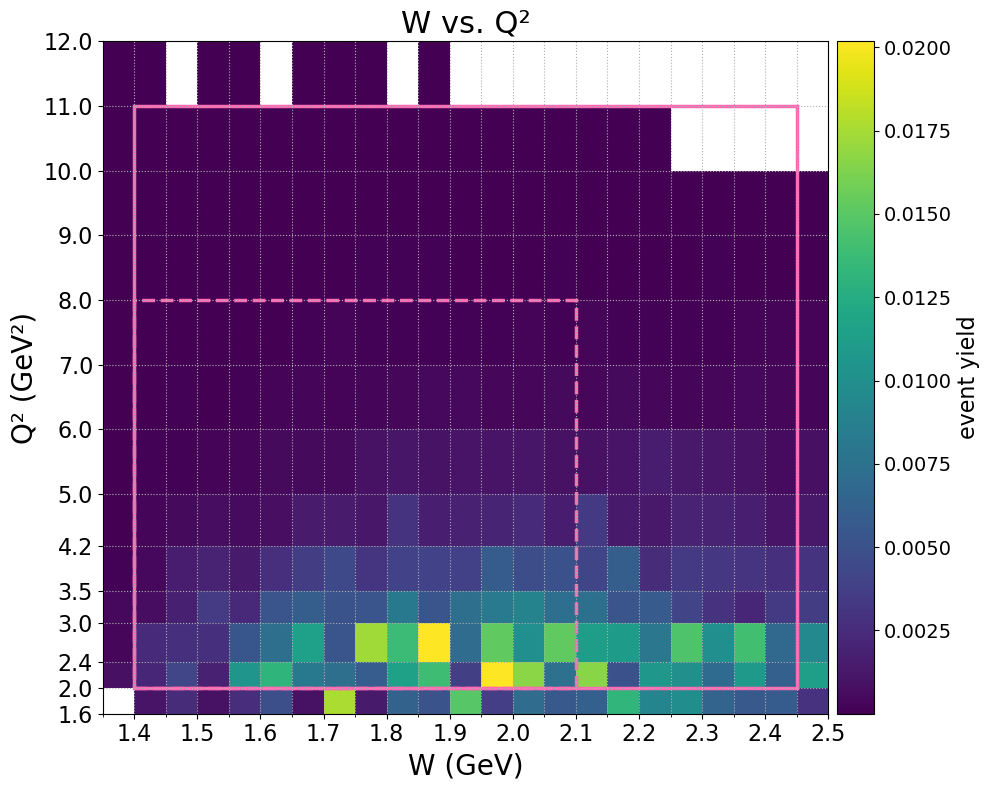

In [8]:
# Define which dataset to visualize
dataset = df 
# dataset = threepion_csv

# Events with ANY PID mismatch
misid_mask = (
    df["prot_mismatch"] |
    df["pip_mismatch"]  |
    df["pim_mismatch"]
)

# Keep only misidentified events
misid_df = df[misid_mask].copy()

w_range = np.append(np.arange(1.35, 2.5, 0.05), 2.5)
q2_range = [1.6,2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0] #,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0]

###### fine bins
n_w_bins  = 300  #500
n_q2_bins = 300

w_min, w_max   = 1.35, 2.50
q2_min, q2_max = 1.6, 12.0

# --- W vs Q² histograms with colorbars for each topology ---
# Define bin edges from your ranges
bin_x = w_range
bin_y = q2_range

# for topo in topologies:
fig, ax = plt.subplots(figsize=(10, 8))
# mask = dataset["w"].notna() & dataset["q2"].notna()
# w_vals = dataset.loc[mask, "w"].to_numpy()
# q2_vals = dataset.loc[mask, "q2"].to_numpy()
# weights = dataset.loc[mask, "weight"].to_numpy()

# Events with ANY PID mismatch
# misid_mask = (
#     dataset["prot_mismatch"] |
#     dataset["pip_mismatch"]  |
#     dataset["pim_mismatch"]
# )

# mask = (
#     misid_mask &
#     dataset["w"].notna() &
#     dataset["q2"].notna()
# )

# w_vals = dataset.loc[mask, "w"].to_numpy()
# q2_vals = dataset.loc[mask, "q2"].to_numpy()
# weights = dataset.loc[mask, "weight"].to_numpy()

# Keep only rows with valid W and Q2
misid_df = misid_df[
    misid_df["w"].notna() &
    misid_df["q2"].notna()
]

# Arrays for plotting
w_vals = misid_df["w"].to_numpy()
q2_vals = misid_df["q2"].to_numpy()
weights = misid_df["weight"].to_numpy()

# 2D histogram — color represents event density
h = ax.hist2d(w_vals, q2_vals, bins=[bin_x, bin_y], cmap='viridis', cmin=1e-12, weights=weights, density=False)

# Title and axes
ax.set_title(f"W vs. Q²", fontsize=22)
ax.set_xlabel("W (GeV)", fontsize=20)
ax.set_ylabel("Q² (GeV²)", fontsize=20)

# Colorbar setup
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
cb = plt.colorbar(h[3], cax=cax)
cb.set_label("event yield", fontsize=16)
cb.ax.tick_params(labelsize=14)

# Grid and ticks
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xticks(np.append(np.arange(1.4, 2.5, 0.1), 2.5))
ax.set_xticks(bin_x, minor=True) 
ax.set_yticks(bin_y)

# Define analyzed range
w_min_analyzed, w_max_analyzed = 1.4, 2.45
q2_min_analyzed, q2_max_analyzed = 2.0, 11.0

# Create a red rectangle
rect = patches.Rectangle(
    (w_min_analyzed, q2_min_analyzed),  # bottom-left corner
    w_max_analyzed - w_min_analyzed,    # width
    q2_max_analyzed - q2_min_analyzed,  # height
    linewidth=2.5, edgecolor='hotpink', alpha=1.0, facecolor='none')

# Define analyzed range
w_min_analyzed_krishna, w_max_analyzed_krishna = 1.4, 2.10
q2_min_analyzed_krishna, q2_max_analyzed_krishna = 2.0, 8.0

# Create a red rectangle
rect_krishna = patches.Rectangle(
    (w_min_analyzed_krishna, q2_min_analyzed_krishna),  # bottom-left corner
    w_max_analyzed_krishna - w_min_analyzed_krishna,    # width
    q2_max_analyzed_krishna - q2_min_analyzed_krishna,  # height
    linewidth=2.5, edgecolor='hotpink', alpha=1.0, linestyle='--', facecolor='none')

# Add rectangle to the axes
ax.add_patch(rect)
ax.add_patch(rect_krishna)

plt.tight_layout()
plt.show()

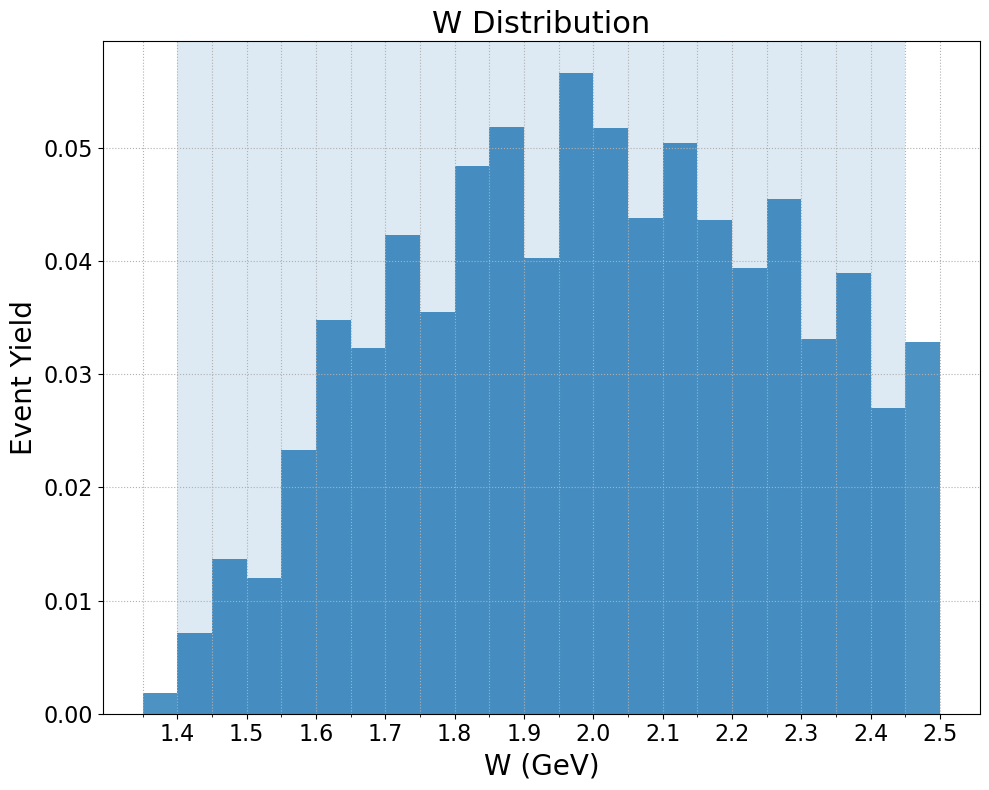

In [23]:
# Define which dataset to visualize
dataset = df
# dataset = threepion_csv

# Events with ANY PID mismatch
misid_mask = (
    dataset["prot_mismatch"] |
    dataset["pip_mismatch"]  |
    dataset["pim_mismatch"]
)

# Keep only misidentified events
misid_df = dataset[misid_mask].copy()

# Keep only rows with valid W values
misid_df = misid_df[misid_df["w"].notna()]

# Arrays for plotting
w_vals = misid_df["w"].to_numpy()
weights = misid_df["weight"].to_numpy()

# W binning
w_bins = np.append(np.arange(1.35, 2.5, 0.05), 2.5)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# 1D weighted histogram
ax.hist(
    w_vals,
    bins=w_bins,
    weights=weights,
    histtype='stepfilled',
    alpha=0.8
)

# Title and labels
ax.set_title("W Distribution", fontsize=22)
ax.set_xlabel("W (GeV)", fontsize=20)
ax.set_ylabel("Event Yield", fontsize=20)

# Grid and ticks
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=16)

ax.set_xticks(np.append(np.arange(1.4, 2.5, 0.1), 2.5))
ax.set_xticks(w_bins, minor=True)

# highlight analyzed region
w_min_analyzed, w_max_analyzed = 1.4, 2.45

ax.axvspan(
    w_min_analyzed,
    w_max_analyzed,
    alpha=0.15
)

plt.tight_layout()
plt.show()

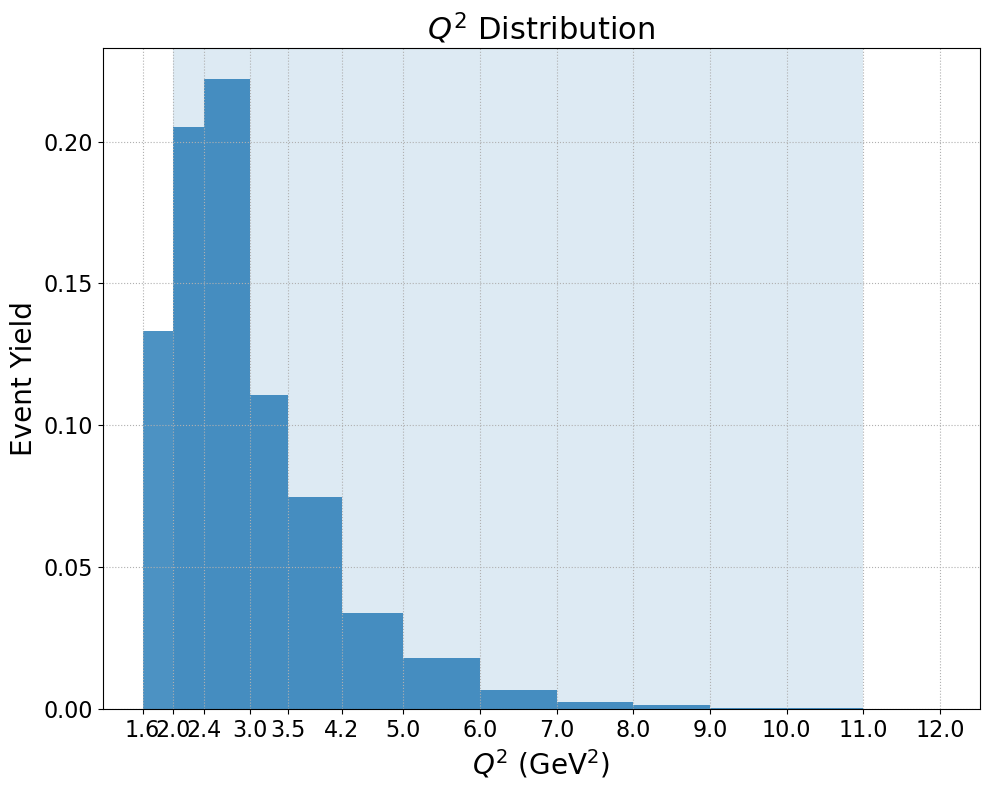

In [25]:
# Define which dataset to visualize
dataset = df
# dataset = threepion_csv

# Events with ANY PID mismatch
misid_mask = (
    dataset["prot_mismatch"] |
    dataset["pip_mismatch"]  |
    dataset["pim_mismatch"]
)

# Keep only misidentified events
misid_df = dataset[misid_mask].copy()

# Keep only rows with valid Q2 values
misid_df = misid_df[misid_df["q2"].notna()]

# Arrays for plotting
q2_vals = misid_df["q2"].to_numpy()
weights = misid_df["weight"].to_numpy()

# Q2 binning
q2_bins = [1.6,2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0]

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# 1D weighted histogram
ax.hist(
    q2_vals,
    bins=q2_bins,
    weights=weights,
    histtype='stepfilled',
    alpha=0.8
)

# Title and labels
ax.set_title(r"$Q^2$ Distribution", fontsize=22)
ax.set_xlabel(r"$Q^2$ (GeV$^2$)", fontsize=20)
ax.set_ylabel("Event Yield", fontsize=20)

# Grid and ticks
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=16)

ax.set_xticks(q2_bins)

# Optional: highlight analyzed region
q2_min_analyzed, q2_max_analyzed = 2.0, 11.0

ax.axvspan(
    q2_min_analyzed,
    q2_max_analyzed,
    alpha=0.15
)

plt.tight_layout()
plt.show()

# load csv

In [16]:
# change folder name to 'experiment' or 'simulation' or 'threepion_sim'
folder_name = "simulation"

# options are fall18_inb, fall18_outb, spring19_inb, spring19_inb_wBG, spring19_inb_noBG_recPID, spring19_inb_noBG_filteredthrownPID, spring19_inb_45nA_recPID, spring19_inb_45nA_misID so far
data_name = "spring19_inb_45nA_misID"

# choose a csv file corresponding to the above folder_name
# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/exp/10_6exp_excl_jlab_11_09_2025.csv", index_col=False)

csv_file = df

# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2rec_excl_sp19inb_wBG_jlab_04_23_2026.csv", index_col=False)
# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2rec_excl_sp19inb_oldsim_jlab_04_21_2026.csv", index_col=False)
# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2exp_excl_sp19inb_jlab_04_21_2026_2.csv", index_col=False)
# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2rec_excl_sp19inb_thrownPID_FILTERED2_local_04_27_2026.csv", index_col=False)
# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_6rec_excl_sp19inb_recPID_local_04_27_2026.csv", index_col=False)
# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2rec_excl_sp19inb_45nA_jlab_04_27_2026.csv", index_col=False)
# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_2GeV/sp19inb/10_2rec_excl_sp19inb_noBG_jlab_04_27_2026_2.csv", index_col=False)

# csv_file = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/10_6rec_excl_fa18outb_jlab_2_12_11_2025.csv", index_col=False)
# csv_file = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/testweight/10_6rec_excl_jlab_09_24_2025.csv", index_col=False)
# csv_file = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/testweight/10_6rec_excl_testweight_jlab_12_02_2024.csv", index_col=False)
# csv_file = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/pass2noBG/10_6rec_excl_pass2noBG_jlab_12_02_2024.csv", index_col=False)
# csv_file = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/22GeV/pass2noBG/22rec_excl_pass2noBG_jlab_12_02_2024.csv", index_col=False)

# csv_file = pd.read_csv("/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/twopeg/fall18_inb/10_6rec_excl_fa18inb_jlab_01_16_2026.csv", index_col=False)

# if exp:
# csv_file["weight"] = 1

# read in threepion background csv (for exp and rec bg comparisons)
threepion_csv = pd.read_csv(f"/Users/aosmond/nuclearPhys/csv/finished_csv/10_6GeV/threepion/10_6rec_excl_3pion_withBG_jlab_07_22_2025.csv", index_col=False)

# base path for future hists
hist_base_path = Path(f'/Users/aosmond/nuclearPhys/notebooks/notebook_hists/{folder_name}/{data_name}/EXCL_topology')
csv_base_path = Path(f'/Users/aosmond/nuclearPhys/notebooks/notebook_csvs/{folder_name}/{data_name}/EXCL_topology')

In [269]:
csv_file.head()

,event,w,q2,weight,mm2_mPim,mm2_mPip,mm2_mProt,mm2_excl,pim_mom_miss,pim_mom_meas,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
0,21,2.066057,2.471006,1,0.439562,0.339199,1.820972,0.137066,1.575342,0.884366,...,0.724776,29.24346,37.99516,25.30761,29.42152,15.57003,14.65086,10.63401,4.454532,5.811574
1,156,2.280641,3.063159,1,0.118704,0.063307,1.264295,-0.007114,1.071911,0.809511,...,0.315932,41.52332,50.91381,14.85064,15.61269,17.07120,23.41612,10.83875,3.120444,6.893301
2,191,1.726268,2.675329,1,-2.322988,-2.322035,0.638682,-2.449522,2.573745,0.501434,...,2.205147,29.77773,59.01657,29.21007,60.90614,24.02611,51.39197,38.75190,40.599140,49.782310
3,291,2.376582,2.160905,1,0.300557,0.283883,1.169842,-0.001512,0.614670,0.427813,...,0.375649,30.67060,67.01896,20.14140,24.59352,14.34736,17.47522,37.05305,5.061890,4.759130
4,448,2.164091,1.860151,1,0.070695,0.047719,0.994116,-0.003372,0.425229,0.344270,...,0.142403,34.97153,52.53758,30.40888,32.43732,20.91687,24.13633,17.61235,2.226481,3.238718


In [270]:
csv_file.tail()

,event,w,q2,weight,mm2_mPim,mm2_mPip,mm2_mProt,mm2_excl,pim_mom_miss,pim_mom_meas,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
6111843,28981426,2.329460,1.789256,1,0.590458,0.178345,1.295736,0.013755,0.408381,0.285118,...,0.540160,31.98389,112.90030,17.41633,12.06546,19.93855,17.81579,100.817300,9.270079,3.688798
6111844,28981478,2.310778,2.131764,1,0.022325,0.038959,0.962858,-0.000173,2.037573,1.958665,...,0.080493,18.48518,18.83784,19.41346,21.04026,40.22148,42.71217,0.455852,1.808316,2.494428
6111845,28981704,2.198743,2.845320,1,0.057501,0.539368,1.689630,-0.026974,1.823790,1.126266,...,0.723494,36.41903,29.71287,32.66726,58.35784,19.23717,10.14667,7.685487,63.982060,9.216394
6111846,28981709,2.349776,2.108409,1,-0.098043,-0.201954,0.611441,0.003839,1.352350,1.484828,...,0.164489,20.30905,20.22896,37.90178,35.31388,33.33393,30.11605,3.943026,4.653647,5.986496
6111847,28981854,1.962831,3.304049,1,0.135516,0.416990,1.390749,0.002442,0.627158,0.595442,...,0.104543,48.82291,39.82360,21.78326,18.25393,26.70730,23.77975,9.350355,4.050853,3.233931


In [271]:
w_min = csv_file["w"].min()
w_max = csv_file["w"].max()

q2_min = csv_file["q2"].min()
q2_max = csv_file["q2"].max()

print("w min:", w_min)
print("w max:", w_max)
print("q2 min:", q2_min)
print("q2 max:", q2_max)


w min: 1.000022
w max: 2.5
q2 min: 1.501599
q2 max: 11.94578


In [18]:
bins_value = 100
step = 0.001

# --- Define MM² ranges for each topology ---
topologies = {
    "excl": (-0.03, 0.03),
    "mProt": (-0.1, 2.5),
    "mPip": (-0.4, 0.6),
    "mPim": (-0.4, 0.6),
}

# w-q2 range

In [9]:
# w and q2 ranges
w_bins = np.append(np.arange(1.4, 2.5, 0.05), 2.5)
q2_bins = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0] #,13.0] ## original range was 8,9,11,13 but I added finer binning (?)
# q2_bins = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0] 

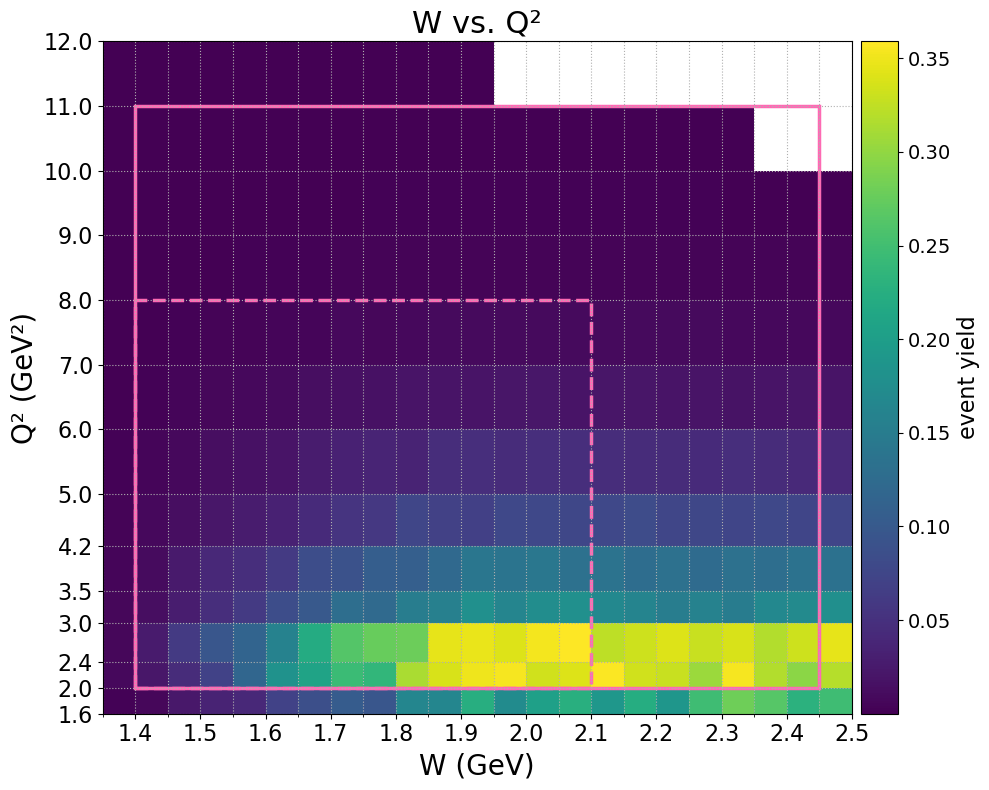

In [11]:
# Define which dataset to visualize
# dataset = csv_file 
# dataset = threepion_csv\
dataset = df

w_range = np.append(np.arange(1.35, 2.5, 0.05), 2.5)
q2_range = [1.6,2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0] #,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0]

###### fine bins
n_w_bins  = 300  #500
n_q2_bins = 300

w_min, w_max   = 1.35, 2.50
q2_min, q2_max = 1.6, 12.0

# --- W vs Q² histograms with colorbars for each topology ---
# Define bin edges from your ranges
bin_x = w_range
bin_y = q2_range

# for topo in topologies:
fig, ax = plt.subplots(figsize=(10, 8))
mask = dataset["w"].notna() & dataset["q2"].notna()
w_vals = dataset.loc[mask, "w"].to_numpy()
q2_vals = dataset.loc[mask, "q2"].to_numpy()
weights = dataset.loc[mask, "weight"].to_numpy()

# 2D histogram — color represents event density
h = ax.hist2d(w_vals, q2_vals, bins=[bin_x, bin_y], cmap='viridis', cmin=1e-12, weights=weights, density=False)

# Title and axes
ax.set_title(f"W vs. Q²", fontsize=22)
ax.set_xlabel("W (GeV)", fontsize=20)
ax.set_ylabel("Q² (GeV²)", fontsize=20)

# Colorbar setup
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
cb = plt.colorbar(h[3], cax=cax)
cb.set_label("event yield", fontsize=16)
cb.ax.tick_params(labelsize=14)

# Grid and ticks
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xticks(np.append(np.arange(1.4, 2.5, 0.1), 2.5))
ax.set_xticks(bin_x, minor=True) 
ax.set_yticks(bin_y)

# Define analyzed range
w_min_analyzed, w_max_analyzed = 1.4, 2.45
q2_min_analyzed, q2_max_analyzed = 2.0, 11.0

# Create a red rectangle
rect = patches.Rectangle(
    (w_min_analyzed, q2_min_analyzed),  # bottom-left corner
    w_max_analyzed - w_min_analyzed,    # width
    q2_max_analyzed - q2_min_analyzed,  # height
    linewidth=2.5, edgecolor='hotpink', alpha=1.0, facecolor='none')

# Define analyzed range
w_min_analyzed_krishna, w_max_analyzed_krishna = 1.4, 2.10
q2_min_analyzed_krishna, q2_max_analyzed_krishna = 2.0, 8.0

# Create a red rectangle
rect_krishna = patches.Rectangle(
    (w_min_analyzed_krishna, q2_min_analyzed_krishna),  # bottom-left corner
    w_max_analyzed_krishna - w_min_analyzed_krishna,    # width
    q2_max_analyzed_krishna - q2_min_analyzed_krishna,  # height
    linewidth=2.5, edgecolor='hotpink', alpha=1.0, linestyle='--', facecolor='none')

# Add rectangle to the axes
ax.add_patch(rect)
ax.add_patch(rect_krishna)

plt.tight_layout()
plt.show()

# w-q2 binned cuts

In [19]:
# w and q2 ranges
w_bins = np.append(np.arange(1.4, 2.5, 0.05), 2.5)
q2_bins = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0] #,13.0]

In [20]:
# --- Initialize cut_results for all systematic cuts ---
cut_results = {
    "mm2": {"in": {}, "out": {}, "all": {}},
    "theta": {"in": {}, "out": {}, "all": {}},
    "momentum": {"in": {}, "out": {}, "all": {}}
}

## mm2 cuts

In [26]:
binned_hist_path = Path("MM2_binned_wq2/mm2_cuts")

# --- Gaussian function ---
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# --- Define MM² topologies ---
topologies_mm2 = {
    "excl":  {"range": (-0.03, 0.03), "fit_window": (-0.02, 0.02)},
    "mProt": {"range": (-0.1, 2.5),   "fit_window": (0.4, 1.25)},
    "mPip":  {"range": (-0.4, 0.6),   "fit_window": (-0.3, 0.2)},
    # "mPim":  {"range": (-0.4, 0.6),   "fit_window": (-0.3, 0.2)},
    "mPim":  {"range": (-2.0, 0.6),   "fit_window": (-0.3, 0.2)},
}

# Choose dataset
dataset = csv_file

# Events with ANY PID mismatch
misid_mask = (
    dataset["prot_mismatch"] |
    dataset["pip_mismatch"]  |
    dataset["pim_mismatch"]
)

# Use only misidentified events
dataset = dataset[misid_mask].copy()

dataset['w_bin'] = pd.cut(dataset['w'], bins=w_bins, labels=False, right=False)
dataset['q2_bin'] = pd.cut(dataset['q2'], bins=q2_bins, labels=False, right=False)
binned_data = dataset.dropna(subset=['w_bin', 'q2_bin'])

# # --- Bin the data ---
# csv_file['w_bin'] = pd.cut(csv_file['w'], bins=w_bins, labels=False, right=False)
# csv_file['q2_bin'] = pd.cut(csv_file['q2'], bins=q2_bins, labels=False, right=False)
# binned_data = csv_file.dropna(subset=['w_bin', 'q2_bin'])

# --- Helpers ---
def bin_label(bin_idx, bin_edges):
    if bin_idx < len(bin_edges) - 1:
        return f"[{bin_edges[bin_idx]:.2f}, {bin_edges[bin_idx + 1]:.2f})"
    return "[out of range)"

def safe_str(label):
    return label.strip("[]()").replace(",", "_").replace(" ", "")

# sigma_factors = np.arange(0.5, 1.75 + 0.001, 0.25)
sigma_factors = [0.5, 1.5, 1.75, 2.0]
cmap = plt.cm.rainbow_r
sigma_colors = cmap(np.linspace(0, 1, len(sigma_factors)))

# --- Process a single (W,Q2) bin ---
def process_bin(group, w_bin, q2_bin, topo, sigma=1.1775):
    """Process a single (w,q2) bin with Gaussian fit cuts for a given MM² topology."""
    w_label = bin_label(w_bin, w_bins)
    q2_label = bin_label(q2_bin, q2_bins)
    column = f"mm2_{topo}"
    x_min, x_max = topologies_mm2[topo]["range"]

    # Histogram over plotting range
    values, bins = np.histogram(group[column].dropna(), bins=bins_value, range=(x_min, x_max))
    bin_centers = (bins[:-1] + bins[1:]) / 2.0

    # initialize fit & cut results
    amp_fit = mean_fit = sigma_fit = None
    left_out = right_out = left_in = right_in = None

    try:
        # --- get user-provided fit window (must be tuple (left, right)) ---
        fit_window = topologies_mm2[topo].get("fit_window", None)
        if fit_window is None:
            raise ValueError(f"No fit_window defined for topology '{topo}'")

        if not (isinstance(fit_window, tuple) and len(fit_window) == 2):
            raise ValueError(f"fit_window for '{topo}' must be a tuple (left, right)")

        fit_window_left, fit_window_right = fit_window

        # --- Restrict fit mask to the intersection of fit_window and plotting range ---
        fit_mask = (bin_centers >= fit_window_left) & (bin_centers <= fit_window_right)

        # If there are no bins inside the fit window, expand to nearest valid bins inside plotting range
        if not np.any(fit_mask):
            # find bins inside plotting range and attempt small fallback (use full plotting range)
            fit_mask = (bin_centers >= x_min) & (bin_centers <= x_max)
            if not np.any(fit_mask):
                raise ValueError("No histogram bins in plotting range to fit.")

        # --- Find peak inside fit window (local peak) ---
        local_values = values[fit_mask]
        local_centers = bin_centers[fit_mask]

        # If all zeros, raise to fallback
        if local_values.sum() == 0:
            raise ValueError("No counts in fit window to determine peak.")

        local_peak_idx = np.argmax(local_values)
        # convert local index back to global index in bin_centers
        global_peak_idx = np.where(fit_mask)[0][local_peak_idx]
        peak_x = bin_centers[global_peak_idx]

        # --- Prepare fit arrays (only inside fit window) ---
        x_fit = local_centers
        y_fit = local_values

        # require at least 3 points to fit a Gaussian robustly
        if len(x_fit) < 3 or y_fit.sum() == 0:
            raise ValueError("Insufficient points in fit window for Gaussian fit.")

        # initial guesses
        amp_guess = float(y_fit.max())
        mean_guess = float(peak_x)
        sigma_guess = max(1e-6, 0.25 * (fit_window_right - fit_window_left))  # avoid zero

        # --- Fit Gaussian only on the fit window data ---
        popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=[amp_guess, mean_guess, sigma_guess], maxfev=20000)
        amp_fit, mean_fit, sigma_fit = popt

        for i, sigma in enumerate(sigma_factors):
            left  = mean_fit - sigma * sigma_fit
            right = mean_fit + sigma * sigma_fit

            inside_df = group[group[column].between(left, right)]
            outside_df = group[~group[column].between(left, right)]

            cut_results.setdefault("mm2", {}).setdefault("in", {})[(w_bin, q2_bin, topo, sigma)] = inside_df
            cut_results.setdefault("mm2", {}).setdefault("out", {})[(w_bin, q2_bin, topo, sigma)] = outside_df

        all_df = group.copy()
        cut_results.setdefault("mm2", {}).setdefault("all", {})[(w_bin, q2_bin, topo)] = all_df

    # except Exception as e:
    #     # Report but continue: fit failed -> leave fit/cut variables as None (or NaN)
    #     print(f"Gaussian fit failed for {topo}, W-bin {w_bin}, Q2-bin {q2_bin}: {e}")
    #     amp_fit = mean_fit = sigma_fit = None
    #     left_in = right_in = left_out = right_out = None
    #     # ensure x_fit/y_fit exist for plotting guard (provide empty arrays)
    #     x_fit = np.array([fit_window_left, fit_window_right]) if 'fit_window_left' in locals() else np.array([x_min, x_max])
    #     y_fit = np.zeros_like(x_fit)

    except Exception as e:
        print(f"Skipping bad bin -> {topo}, W-bin {w_bin}, Q2-bin {q2_bin}: {e}")
        return

    # --- Plot results ---
    plt.figure(figsize=(11, 7))
    plt.hist(group[column].dropna(), bins=bins_value, range=(x_min, x_max), label="all events", alpha=0.8, color='black', histtype='step', linewidth=0.8)

    # Plot fitted Gaussian only if fit succeeded
    if amp_fit is not None and sigma_fit is not None and mean_fit is not None:
        # plot Gaussian only over the fit window (dense sampling)
        x_dense = np.linspace(max(x_min, fit_window_left), min(x_max, fit_window_right), 1000)
        y_dense = gaussian(x_dense, amp_fit, mean_fit, sigma_fit)
        plt.plot(x_dense, y_dense, color='fuchsia', linewidth=1.5, label='gaussian fit')

        # vertical line at fit mean
        plt.axvline(mean_fit, color='fuchsia', linestyle='--', linewidth=1.0, label=f'peak (fit) = {mean_fit:.4f}')

    else:
        # if fit failed, optionally mark the fit window region for debugging
        try:
            plt.axvspan(fit_window_left, fit_window_right, color='gray', alpha=0.08, label='fit window')
        except Exception:
            pass

    # --- Plot multiple in-cuts ---
    for i, sigma in enumerate(sigma_factors):
        left = mean_fit - sigma * sigma_fit
        right = mean_fit + sigma * sigma_fit

        color = sigma_colors[i]
        lw = 1.2
        alpha = 0.9

        plt.axvline(left,  color=color, linestyle='-', linewidth=lw, alpha=alpha)
        plt.axvline(right, color=color, linestyle='-', linewidth=lw, alpha=alpha)
        plt.plot([], [], color=color, linestyle='-', linewidth=lw, alpha=alpha, label=f'±{sigma:.2f}σ')

    # Title & labels
    plt.title(f"{topo} MM²: W {w_label}, Q² {q2_label}", fontsize=25)
    plt.xlabel('MM² [GeV²]', fontsize=20)
    plt.xlim(x_min, x_max)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(alpha=0.5)
    plt.legend(fontsize=14, loc='upper right')

    # Save figure
    outdir = hist_base_path / binned_hist_path / f"mm2cuts_{topo}"
    outdir.mkdir(parents=True, exist_ok=True)
    fname = outdir / f"mm2_W_{safe_str(w_label)}_Q2_{safe_str(q2_label)}.png"
    plt.savefig(fname, dpi=300)
    plt.close()

# --- Main loop over MM² topologies ---
for topo in topologies_mm2:
    total_bins = binned_data.groupby(['w_bin', 'q2_bin']).ngroups
    for i, ((w_bin, q2_bin), group) in enumerate(binned_data.groupby(['w_bin', 'q2_bin']), start=1):
        process_bin(group, int(w_bin), int(q2_bin), topo, sigma=3.0)
        print(f"{topo}: Saved histogram {i}/{total_bins} ({i/total_bins*100:.2f}% complete)", end="\r")
        sys.stdout.flush()
    print()  # new line after each topo

Skipping bad bin -> excl, W-bin 0, Q2-bin 2: No counts in fit window to determine peak.
Skipping bad bin -> excl, W-bin 0, Q2-bin 3: No counts in fit window to determine peak.
Skipping bad bin -> excl, W-bin 0, Q2-bin 5: No counts in fit window to determine peak.
Skipping bad bin -> excl, W-bin 0, Q2-bin 7: No counts in fit window to determine peak.
Skipping bad bin -> excl, W-bin 0, Q2-bin 11: No counts in fit window to determine peak.
Skipping bad bin -> excl, W-bin 0, Q2-bin 12: No counts in fit window to determine peak.
Skipping bad bin -> excl, W-bin 1, Q2-bin 0: No counts in fit window to determine peak.
Skipping bad bin -> excl, W-bin 1, Q2-bin 7: Optimal parameters not found: Number of calls to function has reached maxfev = 20000.
Skipping bad bin -> excl, W-bin 1, Q2-bin 8: No counts in fit window to determine peak.
Skipping bad bin -> excl, W-bin 1, Q2-bin 9: No counts in fit window to determine peak.
Skipping bad bin -> excl, W-bin 1, Q2-bin 11: No counts in fit window to de

## theta cuts

In [278]:
binned_hist_path = Path("MM2_binned_wq2/theta_cuts")

# --- Define topologies ---
topologies_theta = {
    "prot": {"column": "prot_theta_angle_btwn_P", "range": (-1, 25)},
    "pip": {"column": "pip_theta_angle_btwn_P", "range": (-1, 25)},
    "pim": {"column": "pim_theta_angle_btwn_P", "range": (-1, 25)},
}

# --- Bin the data ---
csv_file['w_bin'] = pd.cut(csv_file['w'], bins=w_bins, labels=False, right=False)
csv_file['q2_bin'] = pd.cut(csv_file['q2'], bins=q2_bins, labels=False, right=False)
binned_data = csv_file.dropna(subset=['w_bin', 'q2_bin'])

# --- Helpers ---
def bin_label(bin_idx, bin_edges):
    if bin_idx < len(bin_edges) - 1:
        return f"[{bin_edges[bin_idx]:.2f}, {bin_edges[bin_idx + 1]:.2f})"
    return "[out of range)"

def safe_str(label):
    return label.strip("[]()").replace(",", "_").replace(" ", "")

theta_sigma_factors = np.arange(-0.5, 2.00 + 0.001, 0.5)

# --- Histogram-based FWHM estimation ---
def estimate_fwhm(data, bins=200, range=None):
    hist, edges = np.histogram(data, bins=bins, range=range)
    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    if hist.sum() == 0:
        return None

    # --- Find peak ---
    peak_idx = np.argmax(hist)
    peak_y = hist[peak_idx]
    half_max = peak_y / 2.0

    # --- Find right side where hist falls below half max ---
    right_idx = np.where(hist[peak_idx:] < half_max)[0]
    if len(right_idx) == 0:
        return None

    right_edge = bin_centers[peak_idx + right_idx[0]]
    fwhm = 2 * (right_edge - bin_centers[peak_idx])  # approximate FWHM

    return {
        "mu": bin_centers[peak_idx],
        "fwhm": fwhm,
        "x": bin_centers,
        "y": hist,
    }

# --- Process a single bin ---
def process_bin(group, w_bin, q2_bin, topo): #, sigma_in_factor=1.1775, sigma_out_factor=1.1775):
    w_label = bin_label(w_bin, w_bins)
    q2_label = bin_label(q2_bin, q2_bins)
    column = topologies_theta[topo]["column"]
    x_min, x_max = topologies_theta[topo]["range"]
    fit_res = estimate_fwhm(group[column], bins=bins_value, range=(x_min, x_max))

    if fit_res is None:
        return
    
    mu = fit_res["mu"]
    fwhm = fit_res["fwhm"]
    sigma = fwhm / 2.355
    all_df = group.copy()

    for sigma_in in theta_sigma_factors:
        right_in = mu + sigma_in * sigma
        inside_df = group[group[column] <= right_in]
        outside_df = group[group[column] > right_in]

        cut_results.setdefault("theta", {}).setdefault("in", {})[(w_bin, q2_bin, topo, sigma_in)] = inside_df
        cut_results.setdefault("theta", {}).setdefault("out", {})[(w_bin, q2_bin, topo, sigma_in)] = outside_df
        cut_results.setdefault("theta", {}).setdefault("all", {})[(w_bin, q2_bin, topo, sigma_in)] = all_df

    # --- Plot ---
    plt.figure(figsize=(11, 7))
    plt.hist(group[column], bins=bins_value, range=(x_min, x_max), alpha=0.8, color='black', histtype='step', linewidth=0.8, label='all events')

    cmap = plt.cm.rainbow_r
    sigma_colors = cmap(np.linspace(0, 1, len(theta_sigma_factors)))

    for i, sigma_in in enumerate(theta_sigma_factors):
        right = mu + sigma_in * sigma
        color = sigma_colors[i]

        plt.axvline(right, color=color, linewidth=1.2, label=f"inside cut ≤ {sigma_in:.2f}σ")

    plt.title(fr"{topo} θ btwn $P_{{miss}}$ and $P_{{meas}}$: W {w_label}, Q² {q2_label}", fontsize=25)
    plt.xlabel('θ (degrees)', fontsize=20)
    plt.xlim(x_min, x_max)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(alpha=0.5)
    plt.legend(fontsize=14)

    outdir = hist_base_path / binned_hist_path / f"thetacuts_{topo}"
    outdir.mkdir(parents=True, exist_ok=True)
    fname = outdir / f"theta_W_{safe_str(w_label)}_Q2_{safe_str(q2_label)}.png"
    plt.savefig(fname, dpi=300)
    plt.close()

# --- Main loop ---
for topo in topologies_theta:
    total_bins = binned_data.groupby(['w_bin', 'q2_bin']).ngroups
    for i, ((w_bin, q2_bin), group) in enumerate(binned_data.groupby(['w_bin', 'q2_bin']), start=1):
        process_bin(group, int(w_bin), int(q2_bin), topo) #, sigma_in_factor=4.75, sigma_out_factor=0.375)
        print(f"{topo}: Saved histogram {i}/{total_bins} ({i/total_bins*100:.2f}% complete)", end="\r")
        sys.stdout.flush()
    print()

prot: Saved histogram 238/238 (100.00% complete)
pip: Saved histogram 238/238 (100.00% complete)
pim: Saved histogram 238/238 (100.00% complete)


## momentum cuts

In [279]:
binned_hist_path = Path("MM2_binned_wq2/momentum_cuts")

# --- Gaussian function ---
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# --- Sigma values ---
mom_sigma_factors = np.arange(0.5, 2.5 + 0.001, 1.0) 

# --- Define topologies ---
topologies_momentum = {
    "prot": {"missing": "prot_mom_miss", "measured": "prot_mom_meas", "range": (-1, 2)},
    "pip":  {"missing": "pip_mom_miss",  "measured": "pip_mom_meas",  "range": (-1, 2)},
    "pim":  {"missing": "pim_mom_miss",  "measured": "pim_mom_meas",  "range": (-1, 2)},
}

# --- Bin the data ---
csv_file["w_bin"]  = pd.cut(csv_file["w"],  bins=w_bins,  labels=False, right=False)
csv_file["q2_bin"] = pd.cut(csv_file["q2"], bins=q2_bins, labels=False, right=False)
binned_data = csv_file.dropna(subset=["w_bin", "q2_bin"])

# --- Helpers ---
def bin_label(bin_idx, bin_edges):
    return f"[{bin_edges[bin_idx]:.2f}, {bin_edges[bin_idx + 1]:.2f})"

def safe_str(label):
    return label.strip("[]()").replace(",", "_").replace(" ", "")

# --- Process one (W, Q²) bin ---
def process_momentum_bin(group, w_bin, q2_bin, topo):
    w_label  = bin_label(w_bin, w_bins)
    q2_label = bin_label(q2_bin, q2_bins)

    missing_col  = topologies_momentum[topo]["missing"]
    measured_col = topologies_momentum[topo]["measured"]
    x_min, x_max = topologies_momentum[topo]["range"]

    mom_diff = group[missing_col] - group[measured_col]

    # --- Histogram ---
    values, bins = np.histogram(mom_diff, bins=bins_value, range=(x_min, x_max))
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    try:
        # --- Fit range (important for stability) ---
        fit_min, fit_max = -0.5, 0.3
        mask  = (bin_centers >= fit_min) & (bin_centers <= fit_max)
        fit_x = bin_centers[mask]
        fit_y = values[mask]

        # --- Initial guess ---
        peak_idx   = np.argmax(values)
        amp_guess  = values[peak_idx]
        mean_guess = bin_centers[peak_idx]
        sigma_guess = 0.1

        # # --- Clean fit inputs ---
        # valid_mask = np.isfinite(fit_x) & np.isfinite(fit_y)
        # fit_x = fit_x[valid_mask]
        # fit_y = fit_y[valid_mask]

        # # --- Require enough data ---
        # if len(fit_x) < 5 or fit_y.sum() == 0:
        #     raise ValueError("Insufficient data for fit")

        popt, _ = curve_fit(gaussian, fit_x, fit_y, p0=[amp_guess, mean_guess, sigma_guess], maxfev=5000)
        amp_fit, mean_fit, sigma_fit = popt

        # --- Store all events ---
        cut_results["momentum"]["all"][(w_bin, q2_bin, topo)] = group.copy()

        # --- Multi-sigma cuts ---
        for sigma in mom_sigma_factors:
            left  = mean_fit - sigma * sigma_fit
            right = mean_fit + sigma * sigma_fit

            inside_df  = group[mom_diff.between(left, right)]
            outside_df = group[~mom_diff.between(left, right)]

            cut_results["momentum"]["in"][(w_bin, q2_bin, topo, sigma)]  = inside_df
            cut_results["momentum"]["out"][(w_bin, q2_bin, topo, sigma)] = outside_df

    except Exception as e:
        print(f"⚠️ Momentum fit failed for {topo}, W-bin {w_bin}, Q²-bin {q2_bin}: {e}")
        mean_fit = sigma_fit = np.nan

    # --- Plot ---
    plt.figure(figsize=(11, 7))
    plt.hist(mom_diff, bins=bins_value, range=(x_min, x_max), histtype="step", linewidth=1.0, color="black", label="all events")

    if not np.isnan(mean_fit):
        x_fit = np.linspace(fit_min, fit_max, 500)
        plt.plot(x_fit, gaussian(x_fit, *popt), color="fuchsia", linewidth=1.5, label="gaussian fit")

        cmap = plt.cm.rainbow_r
        sigma_colors = cmap(np.linspace(0, 1, len(mom_sigma_factors)))

        for i, sigma in enumerate(mom_sigma_factors):
            left  = mean_fit - sigma * sigma_fit
            right = mean_fit + sigma * sigma_fit
            color = sigma_colors[i]

            plt.axvline(left,  linestyle="-", linewidth=1.2, color=color)
            plt.axvline(right, linestyle="-", linewidth=1.2, color=color, label=f"inside cut ±{sigma:.1f}σ")

    plt.title(f"{topo} momentum diff: W {w_label}, Q² {q2_label}", fontsize=22)
    plt.xlabel("momentum difference (GeV)", fontsize=18)
    plt.xlim(x_min, x_max)
    plt.grid(alpha=0.4)
    plt.legend(fontsize=13)

    outdir = hist_base_path / binned_hist_path / f"momentumcuts_{topo}"
    outdir.mkdir(parents=True, exist_ok=True)

    fname = outdir / f"momentum_W_{safe_str(w_label)}_Q2_{safe_str(q2_label)}.png"
    plt.savefig(fname, dpi=300)
    plt.close()

# --- Main loop ---
for topo in topologies_momentum:
    total_bins = binned_data.groupby(["w_bin", "q2_bin"]).ngroups
    for i, ((w_bin, q2_bin), group) in enumerate(binned_data.groupby(["w_bin", "q2_bin"]), start=1):
        process_momentum_bin(group, int(w_bin), int(q2_bin), topo)
        print(f"{topo}: {i}/{total_bins} " f"({i / total_bins * 100:.2f}%)", end="\r")
        sys.stdout.flush()
    print()

prot: 238/238 (100.00%)
pip: 238/238 (100.00%)
pim: 238/238 (100.00%)


## enhanced signal

In [ ]:
# ------------------- choose one (mm2, theta, momentum) to scan sigma values, assign fixed sigmas to others -------------------
# MM² sigma control
SCAN_MM2_SIGMA = True      # True → plot all σ (comparison mode)
FIXED_MM2_SIGMA_SIG = 1.75      # Used only if SCAN_MM2_SIGMA = False
                                # 1.75 i
# θ sigma control
SCAN_THETA_SIGMA = False      # True → compare θ σ
FIXED_THETA_SIGMA_SIG = 1.5     # Used if SCAN_THETA_SIGMA = False

# Momentum sigma control
SCAN_MOMENTUM_SIGMA = False     # True → compare momentum σ
FIXED_MOMENTUM_SIGMA_SIG = 2.5      # Used if SCAN_MOMENTUM_SIGMA = False


# ------------------- master cut toggle: choose which cuts are applied -------------------
# this is to turn cuts on/off, regardless of scan or fixed mode
USE_MM2 = True
USE_THETA = False
USE_MOMENTUM = True

# ------------------- build organized folder structure based on cuts -------------------
def build_cut_tag():
    tags = []

    # --- Cut usage ---
    if USE_MM2:
        tags.append("mm2")
    if USE_THETA:
        tags.append("theta")
    if USE_MOMENTUM:
        tags.append("momentum")

    if not tags:
        base = "nocuts"
    else:
        base = "_".join(tags) + "_cuts"

    # --- Scan state ---
    scan_tags = []

    if SCAN_MM2_SIGMA:
        scan_tags.append("scanMM2")
    if SCAN_THETA_SIGMA:
        scan_tags.append("scanTheta")
    if SCAN_MOMENTUM_SIGMA:
        scan_tags.append("scanMomentum")

    if scan_tags:
        scan_part = "_".join(scan_tags)
    else:
        scan_part = "fixedSigma"

    return f"{base}__{scan_part}"

cut_tag = build_cut_tag()

binned_mm2_plot_path = (hist_base_path / "MM2_binned_wq2/enhancedsignal" / cut_tag)
binned_mm2_plot_path.mkdir(parents=True, exist_ok=True)

# --- Topologies ---
mm2_topos = ["excl", "mProt", "mPip", "mPim"]
# mm2_topos = ["mProt", "mPip", "mPim"]
theta_topos = ["prot", "pip", "pim"]
momentum_topos = ["prot", "pip", "pim"]

def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

def compute_signal_histogram(w_bin, q2_bin, topo, mm2_sigma, theta_sigma, momentum_sigma):

    df_sig = select_signal_events(
        w_bin, q2_bin, topo,
        mm2_sigma=mm2_sigma if USE_MM2 else None,
        theta_sigma=theta_sigma if USE_THETA else None,
        momentum_sigma=momentum_sigma if USE_MOMENTUM else None
    )

    if df_sig.empty:
        return None, None, None

    mm2_sig = df_sig[f"mm2_{topo}"].dropna()
    if mm2_sig.empty:
        return None, None, None

    sig_counts, sig_bins = np.histogram(mm2_sig, bins=bins_value, range=topologies_mm2[topo]["range"])

    return sig_counts, sig_bins, mm2_sig


# ------------------- Sigma-based signal selection with toggles -------------------
def select_signal_events(w_bin, q2_bin, primary_topo, mm2_sigma=None, theta_sigma=None, momentum_sigma=None):
    """
    Enhanced signal definition:
    - Start from ALL events in the W,Q² bin
    - DO NOT apply σ cut on primary topology
    - Apply σ cuts only on OTHER MM² topologies (if USE_MM2)
    - Apply θ / momentum cuts only if toggled on
    """

    # --- Start from ALL events ---
    df_all = cut_results["mm2"]["all"].get((w_bin, q2_bin, primary_topo), pd.DataFrame(columns=["event", f"mm2_{primary_topo}"]))

    if df_all.empty:
        return pd.DataFrame(columns=["event", f"mm2_{primary_topo}"])

    df = df_all[["event", f"mm2_{primary_topo}"]].copy()

    # --- MM² cuts on OTHER topologies ---
    if USE_MM2 and mm2_sigma is not None:
        for other_topo in mm2_topos:
            if other_topo == primary_topo:
                continue
            df_other_in = cut_results["mm2"]["in"].get((w_bin, q2_bin, other_topo, mm2_sigma))
            # if df_other_in is not None and not df_other_in.empty:
            #     df = df.merge(df_other_in[["event"]], on="event", how="inner")
            if df_other_in is None or df_other_in.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_other_in[["event"]], on="event", how="inner")

    # --- θ cuts ---
    if USE_THETA and theta_sigma is not None:
        for particle in theta_topos:
            df_theta_in = cut_results["theta"]["in"].get((w_bin, q2_bin, particle, theta_sigma))
            # if df_theta_in is not None and not df_theta_in.empty:
            #     df = df.merge(df_theta_in[["event"]], on="event", how="inner")
            if df_theta_in is None or df_theta_in.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_theta_in[["event"]], on="event", how="inner")

    # --- Momentum cuts ---
    if USE_MOMENTUM and momentum_sigma is not None:
        for particle in momentum_topos:
            df_mom_in = cut_results["momentum"]["in"].get((w_bin, q2_bin, particle, momentum_sigma))
            # if df_mom_in is not None and not df_mom_in.empty:
            #     df = df.merge(df_mom_in[["event"]], on="event", how="inner")
            if df_mom_in is None or df_mom_in.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_mom_in[["event"]], on="event", how="inner")

    return df

# --- Plot σ-comparison signal histograms ---
def save_sigma_comparison_mm2_signal():

    for w_bin in range(len(w_bins)-1):
        w_min, w_max = w_bins[w_bin], w_bins[w_bin+1]
        w_label = f"[{w_min:.2f}, {w_max:.2f})"

        for q2_bin in range(len(q2_bins)-1):
            q2_min, q2_max = q2_bins[q2_bin], q2_bins[q2_bin+1]
            q2_label = f"[{q2_min:.2f}, {q2_max:.2f})"

            for topo in mm2_topos:

                df_all = cut_results["mm2"]["all"].get((w_bin, q2_bin, topo), pd.DataFrame(columns=["event", f"mm2_{topo}"]))

                if df_all.empty:
                    continue

                mm2_all = df_all[f"mm2_{topo}"].dropna()
                if mm2_all.empty:
                    continue

                plt.figure(figsize=(8,5))

                # --- All events histogram (compute max bin height) ---
                all_counts, bin_edges = np.histogram(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"])
                all_max = all_counts.max()
                plt.hist(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"], histtype="step", color="black", linewidth=1.0, alpha=0.5, label="all events")

                plotted_any = False
                sigma_axes = []

                if USE_MM2:
                    mm2_sigmas_to_plot = sigma_factors if SCAN_MM2_SIGMA else [FIXED_MM2_SIGMA_SIG]
                    sigma_axes.append(mm2_sigmas_to_plot)
                else:
                    sigma_axes.append([None])

                if USE_THETA:
                    theta_sigmas_to_plot = theta_sigma_factors if SCAN_THETA_SIGMA else [FIXED_THETA_SIGMA_SIG]
                    sigma_axes.append(theta_sigmas_to_plot)
                else:
                    sigma_axes.append([None])

                if USE_MOMENTUM:
                    momentum_sigmas_to_plot = mom_sigma_factors if SCAN_MOMENTUM_SIGMA else [FIXED_MOMENTUM_SIGMA_SIG]
                    sigma_axes.append(momentum_sigmas_to_plot)
                else:
                    sigma_axes.append([None])

                sigma_combos = list(itertools.product(*sigma_axes))
                colors = plt.cm.rainbow_r(np.linspace(0, 1, len(sigma_combos)))

                for i, (mm2_sigma, theta_sigma, momentum_sigma) in enumerate(sigma_combos):

                    sig_counts, sig_bins, mm2_sig = compute_signal_histogram(w_bin, q2_bin, topo, mm2_sigma, theta_sigma, momentum_sigma)

                    if sig_counts is None:
                        continue

                    sig_max = sig_counts.max()
                    if sig_max == 0:
                        continue

                    # mm2_sig = select_signal_events(w_bin, q2_bin, topo, mm2_sigma, theta_sigma, momentum_sigma)[f"mm2_{topo}"].dropna()
                    scale = all_max / sig_max
                    weights = np.full(len(mm2_sig), scale)
                    plotted_any = True

                    label_parts = []
                    if USE_MM2:
                        label_parts.append(f"MM² {mm2_sigma:.2f}σ") #, scale factor: {scale:.2f}")
                    if USE_THETA:
                        label_parts.append(f"θ {theta_sigma:.2f}σ") #, scale factor: {scale:.2f}")
                    if USE_MOMENTUM:
                        label_parts.append(f"p {momentum_sigma:.2f}σ")

                    label = "; ".join(label_parts)
                    label += f"; scale: {scale:.2f}"

                    plt.hist(mm2_sig, bins=bins_value, range=topologies_mm2[topo]["range"], histtype="step", linewidth=0.8, alpha=0.75, color=colors[i], weights=weights, label=label)

                if not plotted_any:
                    plt.close()
                    continue

                plt.title(f"MM² {topo}: W {w_label}, Q² {q2_label}", fontsize=18)
                plt.xlabel("MM² [GeV²]", fontsize=14)
                # plt.ylabel("Counts", fontsize=14)
                plt.xlim(topologies_mm2[topo]["range"])
                plt.grid(alpha=0.3)
                plt.legend(fontsize=8)

                outdir = binned_mm2_plot_path / topo
                outdir.mkdir(parents=True, exist_ok=True)

                fname = outdir / (f"MM2_{topo}_W_{w_min:.2f}-{w_max:.2f}_Q2_{q2_min:.2f}-{q2_max:.2f}.png")

                plt.savefig(fname, dpi=300)
                plt.close()

# --- Execute ---
save_sigma_comparison_mm2_signal()
print("Saved σ-comparison MM² enhanced signal histograms. 🐌")

Saved σ-comparison MM² enhanced signal histograms. 🐌


: 

## enhanced background

In [228]:
# MM² sigma control
SCAN_MM2_SIGMA = True      # True → plot all σ (comparison mode)
FIXED_MM2_SIGMA_BG = 0.5      # Used only if SCAN_MM2_SIGMA = False

# θ sigma control
SCAN_THETA_SIGMA = False      # True → compare θ σ
FIXED_THETA_SIGMA_BG = 0.0     # Used if SCAN_THETA_SIGMA = False

# Momentum sigma control
SCAN_MOMENTUM_SIGMA = False     # True → compare momentum σ
FIXED_MOMENTUM_SIGMA_BG = 0.5      # Used if SCAN_MOMENTUM_SIGMA = False


# --- Toggle individual cuts ---
# this is to turn cuts on/off, regardless of scan or fixed mode
BG_USE_MM2 = True
BG_USE_THETA = False
BG_USE_MOMENTUM = True

def build_cut_tag():
    tags = []

    # --- Cut usage ---
    if BG_USE_MM2:
        tags.append("mm2")
    if BG_USE_THETA:
        tags.append("theta")
    if BG_USE_MOMENTUM:
        tags.append("momentum")

    if not tags:
        base = "nocuts"
    else:
        base = "_".join(tags) + "_cuts"

    # --- Scan state ---
    scan_tags = []

    if SCAN_MM2_SIGMA:
        scan_tags.append("scanMM2")
    if SCAN_THETA_SIGMA:
        scan_tags.append("scanTheta")
    if SCAN_MOMENTUM_SIGMA:
        scan_tags.append("scanMomentum")

    if scan_tags:
        scan_part = "_".join(scan_tags)
    else:
        scan_part = "fixedSigma"

    return f"{base}__{scan_part}"

cut_tag = build_cut_tag()

binned_mm2_plot_path = (hist_base_path / "MM2_binned_wq2/enhancedbackground" / cut_tag)
binned_mm2_plot_path.mkdir(parents=True, exist_ok=True)

# --- Topologies ---
mm2_topos = ["excl", "mProt", "mPip", "mPim"]
# mm2_topos = ["mProt", "mPip", "mPim"]
theta_topos = ["prot", "pip", "pim"]
momentum_topos = ["prot", "pip", "pim"]

def compute_bg_scale(bin_centers, bg_counts, all_counts):
    """
    Statistically optimal background scaling using BOTH sidebands
    via weighted least squares (Poisson uncertainties).
    """

    # --- Define sidebands (both sides together) ---
    mask = (bin_centers < -0.2) | (bin_centers > 0.275)

    B = bg_counts[mask]
    D = all_counts[mask]

    # --- Remove bins with zero background (avoid divide-by-zero) ---
    valid = B > 0
    B = B[valid]
    D = D[valid]

    if len(B) == 0:
        return None

    # --- Poisson uncertainties (σ² ≈ D) ---
    # avoid zero weights
    weights = 1.0 / np.maximum(D, 1)

    # --- Weighted least squares solution for scale ---
    numerator = np.sum(weights * B * D)
    denominator = np.sum(weights * B * B)

    if denominator == 0:
        return None

    scale = numerator / denominator

    return scale

# --- Sigma-based signal selection with toggles ---
def select_background_events(w_bin, q2_bin, primary_topo, mm2_sigma=None, theta_sigma=None, momentum_sigma=None):
    """
    Background definition:
    - Start from ALL events in the W,Q² bin
    - NO cut on primary MM² topology
    - Apply OUTSIDE σ cuts on OTHER MM² topologies
    - Optionally apply OUTSIDE σ cuts on θ and momentum
    """

    # --- Start from ALL events ---
    df_all = cut_results["mm2"]["all"].get((w_bin, q2_bin, primary_topo), pd.DataFrame(columns=["event", f"mm2_{primary_topo}"]))
    if df_all.empty:
        return pd.DataFrame(columns=["event", f"mm2_{primary_topo}"])

    df = df_all[["event", f"mm2_{primary_topo}"]].copy()

    # # --- MM² OUT cuts on OTHER topologies (AND logic) ---
    if BG_USE_MM2 and mm2_sigma is not None:
        for other_topo in mm2_topos:
            if other_topo == primary_topo:
                continue

            df_other_out = cut_results["mm2"]["out"].get((w_bin, q2_bin, other_topo, mm2_sigma))

            if df_other_out is None or df_other_out.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_other_out[["event"]], on="event", how="inner")

    # #### for 2/3 rather than 3/3 requirement for mm2 cuts
    #     pass_counts = 0
    #     required = 2   # <-- THIS IS YOUR CONTROL KNOB\

    #     for other_topo in mm2_topos:
    #         if other_topo == primary_topo:
    #             continue

    #         df_other_out = cut_results["mm2"]["out"].get((w_bin, q2_bin, other_topo, mm2_sigma))

    #         if df_other_out is None or df_other_out.empty:
    #             continue   # <-- IMPORTANT CHANGE

    #         tmp = df.merge(df_other_out[["event"]], on="event", how="inner")

    #         if len(tmp) > 0:
    #             df = tmp
    #             pass_counts += 1

    # if pass_counts < required:
    #     return pd.DataFrame(columns=df.columns)

    # --- θ OUT cuts ---
    if BG_USE_THETA and theta_sigma is not None:
        for particle in theta_topos:
            df_theta_out = cut_results["theta"]["out"].get((w_bin, q2_bin, particle, theta_sigma))

            if df_theta_out is None or df_theta_out.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_theta_out[["event"]], on="event", how="inner")

    # --- Momentum OUT cuts ---
    if BG_USE_MOMENTUM and momentum_sigma is not None:
        for particle in momentum_topos:
            df_mom_out = cut_results["momentum"]["out"].get((w_bin, q2_bin, particle, momentum_sigma))

            if df_mom_out is None or df_mom_out.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_mom_out[["event"]], on="event", how="inner")

    return df

# --- Plot σ-comparison signal histograms ---
def save_sigma_comparison_mm2_background():

    for w_bin in range(len(w_bins)-1):
        w_min, w_max = w_bins[w_bin], w_bins[w_bin+1]
        w_label = f"[{w_min:.2f}, {w_max:.2f})"

        for q2_bin in range(len(q2_bins)-1):
            q2_min, q2_max = q2_bins[q2_bin], q2_bins[q2_bin+1]
            q2_label = f"[{q2_min:.2f}, {q2_max:.2f})"

            for topo in mm2_topos:

                df_all = cut_results["mm2"]["all"].get((w_bin, q2_bin, topo), pd.DataFrame(columns=["event", f"mm2_{topo}"]))

                if df_all.empty:
                    continue

                mm2_all = df_all[f"mm2_{topo}"].dropna()
                if mm2_all.empty:
                    continue

                plt.figure(figsize=(8,5))

                # --- All events histogram (compute max bin height) ---
                all_counts, bin_edges = np.histogram(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"])
                all_max = all_counts.max()
                plt.hist(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"], histtype="step", color="black", linewidth=1.0, alpha=0.5, label="all events")

                plotted_any = False
                sigma_axes = []

                if BG_USE_MM2:
                    mm2_sigmas_to_plot = sigma_factors if SCAN_MM2_SIGMA else [FIXED_MM2_SIGMA_BG]
                    sigma_axes.append(mm2_sigmas_to_plot)
                else:
                    sigma_axes.append([None])

                if BG_USE_THETA:
                    theta_sigmas_to_plot = theta_sigma_factors if SCAN_THETA_SIGMA else [FIXED_THETA_SIGMA_BG]
                    sigma_axes.append(theta_sigmas_to_plot)
                else:
                    sigma_axes.append([None])

                if BG_USE_MOMENTUM:
                    momentum_sigmas_to_plot = mom_sigma_factors if SCAN_MOMENTUM_SIGMA else [FIXED_MOMENTUM_SIGMA_BG]
                    sigma_axes.append(momentum_sigmas_to_plot)
                else:
                    sigma_axes.append([None])

                sigma_combos = list(itertools.product(*sigma_axes))
                colors = plt.cm.rainbow_r(np.linspace(0, 1, len(sigma_combos)))

                for i, (mm2_sigma, theta_sigma, momentum_sigma) in enumerate(sigma_combos):

                    df_bg = select_background_events(w_bin, q2_bin, topo,
                        mm2_sigma=mm2_sigma if BG_USE_MM2 else None,
                        theta_sigma=theta_sigma if BG_USE_THETA else None,
                        momentum_sigma=momentum_sigma if BG_USE_MOMENTUM else None
                        )

                    if df_bg.empty:
                        continue

                    mm2_bg = df_bg[f"mm2_{topo}"].dropna()
                    if mm2_bg.empty:
                        continue

                    # --- Histogram counts ---
                    bg_counts, bg_bins = np.histogram(mm2_bg, bins=bins_value, range=topologies_mm2[topo]["range"])
                    bin_centers = 0.5 * (bg_bins[:-1] + bg_bins[1:])
                    scale = compute_bg_scale(bin_centers, bg_counts, all_counts)

                    if scale is None:
                        continue

                    weights = np.full(len(mm2_bg), scale)
                    plotted_any = True

                    label_parts = []
                    if BG_USE_MM2:
                        label_parts.append(f"MM² {mm2_sigma:.2f}σ") #, scale factor: {scale:.2f}")
                    if BG_USE_THETA:
                        label_parts.append(f"θ {theta_sigma:.2f}σ") #, scale factor: {scale:.2f}")
                    if BG_USE_MOMENTUM:
                        label_parts.append(f"p {momentum_sigma:.2f}σ")

                    label = "; ".join(label_parts)
                    label += f"; scale: {scale:.2f}"

                    plt.hist(mm2_bg, bins=bins_value, range=topologies_mm2[topo]["range"], histtype="step", linewidth=0.8, alpha=0.75, color=colors[i], label=label) #, weights=weights)

                if not plotted_any:
                    plt.close()
                    continue

                plt.title(f"MM² {topo}: W {w_label}, Q² {q2_label}", fontsize=18)
                plt.xlabel("MM² [GeV²]", fontsize=14)
                # plt.ylabel("Counts", fontsize=14)
                plt.xlim(topologies_mm2[topo]["range"])
                plt.grid(alpha=0.3)
                plt.legend(fontsize=8)

                outdir = binned_mm2_plot_path / topo
                outdir.mkdir(parents=True, exist_ok=True)

                fname = outdir / (f"MM2_{topo}_W_{w_min:.2f}-{w_max:.2f}_Q2_{q2_min:.2f}-{q2_max:.2f}.png")

                plt.savefig(fname, dpi=300)
                plt.close()

# --- Execute ---
save_sigma_comparison_mm2_background()
print("Saved σ-comparison enhanced background histograms. 🐌")

Saved σ-comparison enhanced background histograms. 🐌


In [ ]:
## old scaling with cutoff at W 1.65 for left or right sideband scaling

# # MM² sigma control
# SCAN_MM2_SIGMA = True      # True → plot all σ (comparison mode)
# FIXED_MM2_SIGMA_BG = 0.5      # Used only if SCAN_MM2_SIGMA = False

# # θ sigma control
# SCAN_THETA_SIGMA = False      # True → compare θ σ
# FIXED_THETA_SIGMA_BG = 0.0     # Used if SCAN_THETA_SIGMA = False

# # Momentum sigma control
# SCAN_MOMENTUM_SIGMA = False     # True → compare momentum σ
# FIXED_MOMENTUM_SIGMA_BG = 0.5      # Used if SCAN_MOMENTUM_SIGMA = False


# # --- Toggle individual cuts ---
# # this is to turn cuts on/off, regardless of scan or fixed mode
# USE_MM2 = True
# USE_THETA = False
# USE_MOMENTUM = True

# def build_cut_tag():
#     tags = []

#     # --- Cut usage ---
#     if USE_MM2:
#         tags.append("mm2")
#     if USE_THETA:
#         tags.append("theta")
#     if USE_MOMENTUM:
#         tags.append("momentum")

#     if not tags:
#         base = "nocuts"
#     else:
#         base = "_".join(tags) + "_cuts"

#     # --- Scan state ---
#     scan_tags = []

#     if SCAN_MM2_SIGMA:
#         scan_tags.append("scanMM2")
#     if SCAN_THETA_SIGMA:
#         scan_tags.append("scanTheta")
#     if SCAN_MOMENTUM_SIGMA:
#         scan_tags.append("scanMomentum")

#     if scan_tags:
#         scan_part = "_".join(scan_tags)
#     else:
#         scan_part = "fixedSigma"

#     return f"{base}__{scan_part}"

# cut_tag = build_cut_tag()

# binned_mm2_plot_path = (hist_base_path / "MM2_binned_wq2/enhancedbackground" / cut_tag)
# binned_mm2_plot_path.mkdir(parents=True, exist_ok=True)

# # --- Topologies ---
# mm2_topos = ["excl", "mProt", "mPip", "mPim"]
# theta_topos = ["prot", "pip", "pim"]
# momentum_topos = ["prot", "pip", "pim"]

# def compute_bg_scale(w_min, bin_centers, bg_counts, all_counts):
#     """
#     Compute background normalization using the same logic everywhere.
#     """

#     # Choose sideband based on W
#     if w_min <= 1.65:
#         side_mask = bin_centers < -0.3
#     else:
#         side_mask = bin_centers > 0.3

#     bg_side  = bg_counts[side_mask].sum()
#     all_side = all_counts[side_mask].sum()

#     # Safety protection
#     if bg_side == 0:
#         return None

#     return all_side / bg_side

# # --- Sigma-based signal selection with toggles ---
# def select_background_events(w_bin, q2_bin, primary_topo, mm2_sigma=None, theta_sigma=None, momentum_sigma=None):
#     """
#     Background definition:
#     - Start from ALL events in the W,Q² bin
#     - NO cut on primary MM² topology
#     - Apply OUTSIDE σ cuts on OTHER MM² topologies
#     - Optionally apply OUTSIDE σ cuts on θ and momentum
#     """

#     # --- Start from ALL events ---
#     df_all = cut_results["mm2"]["all"].get((w_bin, q2_bin, primary_topo), pd.DataFrame(columns=["event", f"mm2_{primary_topo}"]))
#     if df_all.empty:
#         return pd.DataFrame(columns=["event", f"mm2_{primary_topo}"])

#     df = df_all[["event", f"mm2_{primary_topo}"]].copy()

#     # --- MM² OUT cuts on OTHER topologies (AND logic) ---
#     if USE_MM2 and mm2_sigma is not None:
#         for other_topo in mm2_topos:
#             if other_topo == primary_topo:
#                 continue

#             df_other_out = cut_results["mm2"]["out"].get((w_bin, q2_bin, other_topo, mm2_sigma))

#             if df_other_out is None or df_other_out.empty:
#                 return pd.DataFrame(columns=df.columns)

#             df = df.merge(df_other_out[["event"]], on="event", how="inner")

#     # --- θ OUT cuts ---
#     if USE_THETA and theta_sigma is not None:
#         for particle in theta_topos:
#             df_theta_out = cut_results["theta"]["out"].get((w_bin, q2_bin, particle, theta_sigma))

#             if df_theta_out is None or df_theta_out.empty:
#                 return pd.DataFrame(columns=df.columns)

#             df = df.merge(df_theta_out[["event"]], on="event", how="inner")

#     # --- Momentum OUT cuts ---
#     if USE_MOMENTUM and momentum_sigma is not None:
#         for particle in momentum_topos:
#             df_mom_out = cut_results["momentum"]["out"].get((w_bin, q2_bin, particle, momentum_sigma))

#             if df_mom_out is None or df_mom_out.empty:
#                 return pd.DataFrame(columns=df.columns)

#             df = df.merge(df_mom_out[["event"]], on="event", how="inner")

#     return df

# # --- Plot σ-comparison signal histograms ---
# def save_sigma_comparison_mm2():

#     for w_bin in range(len(w_bins)-1):
#         w_min, w_max = w_bins[w_bin], w_bins[w_bin+1]
#         w_label = f"[{w_min:.2f}, {w_max:.2f})"

#         for q2_bin in range(len(q2_bins)-1):
#             q2_min, q2_max = q2_bins[q2_bin], q2_bins[q2_bin+1]
#             q2_label = f"[{q2_min:.2f}, {q2_max:.2f})"

#             for topo in mm2_topos:

#                 df_all = cut_results["mm2"]["all"].get((w_bin, q2_bin, topo), pd.DataFrame(columns=["event", f"mm2_{topo}"]))

#                 if df_all.empty:
#                     continue

#                 mm2_all = df_all[f"mm2_{topo}"].dropna()
#                 if mm2_all.empty:
#                     continue

#                 plt.figure(figsize=(8,5))

#                 # --- All events histogram (compute max bin height) ---
#                 all_counts, bin_edges = np.histogram(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"])
#                 all_max = all_counts.max()
#                 plt.hist(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"], histtype="step", color="black", linewidth=1.0, alpha=0.5, label="all events")

#                 plotted_any = False
#                 sigma_axes = []

#                 if USE_MM2:
#                     mm2_sigmas_to_plot = sigma_factors if SCAN_MM2_SIGMA else [FIXED_MM2_SIGMA_BG]
#                     sigma_axes.append(mm2_sigmas_to_plot)
#                 else:
#                     sigma_axes.append([None])

#                 if USE_THETA:
#                     theta_sigmas_to_plot = theta_sigma_factors if SCAN_THETA_SIGMA else [FIXED_THETA_SIGMA_BG]
#                     sigma_axes.append(theta_sigmas_to_plot)
#                 else:
#                     sigma_axes.append([None])

#                 if USE_MOMENTUM:
#                     momentum_sigmas_to_plot = mom_sigma_factors if SCAN_MOMENTUM_SIGMA else [FIXED_MOMENTUM_SIGMA_BG]
#                     sigma_axes.append(momentum_sigmas_to_plot)
#                 else:
#                     sigma_axes.append([None])

#                 sigma_combos = list(itertools.product(*sigma_axes))
#                 colors = plt.cm.rainbow_r(np.linspace(0, 1, len(sigma_combos)))

#                 for i, (mm2_sigma, theta_sigma, momentum_sigma) in enumerate(sigma_combos):

#                     df_bg = select_background_events(w_bin, q2_bin, topo,
#                         mm2_sigma=mm2_sigma if USE_MM2 else None,
#                         theta_sigma=theta_sigma if USE_THETA else None,
#                         momentum_sigma=momentum_sigma if USE_MOMENTUM else None
#                         )

#                     if df_bg.empty:
#                         continue

#                     mm2_bg = df_bg[f"mm2_{topo}"].dropna()
#                     if mm2_bg.empty:
#                         continue

#                     # --- Histogram counts ---
#                     bg_counts, bg_bins = np.histogram(mm2_bg, bins=bins_value, range=topologies_mm2[topo]["range"])
#                     bin_centers = 0.5 * (bg_bins[:-1] + bg_bins[1:])
#                     scale = compute_bg_scale(w_min, bin_centers, bg_counts, all_counts)

#                     if scale is None:
#                         continue

#                     weights = np.full(len(mm2_bg), scale)
#                     plotted_any = True

#                     label_parts = []
#                     if USE_MM2:
#                         label_parts.append(f"MM² {mm2_sigma:.2f}σ") #, scale factor: {scale:.2f}")
#                     if USE_THETA:
#                         label_parts.append(f"θ {theta_sigma:.2f}σ") #, scale factor: {scale:.2f}")
#                     if USE_MOMENTUM:
#                         label_parts.append(f"p {momentum_sigma:.2f}σ")

#                     label = "; ".join(label_parts)
#                     label += f"; scale: {scale:.2f}"

#                     plt.hist(mm2_bg, bins=bins_value, range=topologies_mm2[topo]["range"], histtype="step", linewidth=0.8, alpha=0.75, color=colors[i], label=label, weights=weights)

#                 if not plotted_any:
#                     plt.close()
#                     continue

#                 plt.title(f"MM² {topo}: W {w_label}, Q² {q2_label}", fontsize=18)
#                 plt.xlabel("MM² [GeV²]", fontsize=14)
#                 # plt.ylabel("Counts", fontsize=14)
#                 plt.xlim(topologies_mm2[topo]["range"])
#                 plt.grid(alpha=0.3)
#                 plt.legend(fontsize=8)

#                 outdir = binned_mm2_plot_path / topo
#                 outdir.mkdir(parents=True, exist_ok=True)

#                 fname = outdir / (f"MM2_{topo}_W_{w_min:.2f}-{w_max:.2f}_Q2_{q2_min:.2f}-{q2_max:.2f}.png")

#                 plt.savefig(fname, dpi=300)
#                 plt.close()

# # --- Execute ---
# save_sigma_comparison_mm2()
# print("Saved σ-comparison enhanced background histograms. 🐌")

## signal + bg vs all events

### old scaling

In [ ]:
fixed_signal = 2.0

# --- Toggle individual cuts ---
USE_MM2 = True
USE_THETA = True
USE_MOMENTUM = True

binned_mm2_plot_path = (hist_base_path / "MM2_binned_wq2/signal_plus_bg" / cut_tag)
binned_mm2_plot_path.mkdir(parents=True, exist_ok=True)

# --- Topologies ---
mm2_topos = ["excl", "mProt", "mPip", "mPim"]
theta_topos = ["prot", "pip", "pim"]
momentum_topos = ["prot", "pip", "pim"]

# --- Background Selection ---
def select_background_events(w_bin, q2_bin, primary_topo, mm2_sigma=None, theta_sigma=None, momentum_sigma=None):

    df_all = cut_results["mm2"]["all"].get((w_bin, q2_bin, primary_topo), pd.DataFrame(columns=["event", f"mm2_{primary_topo}"]))

    if df_all.empty:
        return pd.DataFrame(columns=["event", f"mm2_{primary_topo}"])

    df = df_all[["event", f"mm2_{primary_topo}"]].copy()

    # MM² OUT cuts on other topologies
    if USE_MM2 and mm2_sigma is not None:
        for other_topo in mm2_topos:
            if other_topo == primary_topo:
                continue

            df_other_out = cut_results["mm2"]["out"].get((w_bin, q2_bin, other_topo, mm2_sigma))

            if df_other_out is None or df_other_out.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_other_out[["event"]], on="event", how="inner")

    # θ OUT cuts
    if USE_THETA and theta_sigma is not None:
        for particle in theta_topos:
            df_theta_out = cut_results["theta"]["out"].get((w_bin, q2_bin, particle, theta_sigma))

            if df_theta_out is None or df_theta_out.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_theta_out[["event"]], on="event", how="inner")

    # Momentum OUT cuts
    if USE_MOMENTUM and momentum_sigma is not None:
        for particle in momentum_topos:
            df_mom_out = cut_results["momentum"]["out"].get((w_bin, q2_bin, particle, momentum_sigma))

            if df_mom_out is None or df_mom_out.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_mom_out[["event"]], on="event", how="inner")

    return df

# --- Plot Function ---
def save_sigma_comparison_mm2():

    fixed_signal_sigma = fixed_signal

    for w_bin in range(len(w_bins)-1):

        w_min, w_max = w_bins[w_bin], w_bins[w_bin+1]
        w_label = f"[{w_min:.2f}, {w_max:.2f})"

        for q2_bin in range(len(q2_bins)-1):

            q2_min, q2_max = q2_bins[q2_bin], q2_bins[q2_bin+1]
            q2_label = f"[{q2_min:.2f}, {q2_max:.2f})"

            for topo in mm2_topos:

                df_all = cut_results["mm2"]["all"].get((w_bin, q2_bin, topo), pd.DataFrame(columns=["event", f"mm2_{topo}"]))

                if df_all.empty:
                    continue

                mm2_all = df_all[f"mm2_{topo}"].dropna()
                if mm2_all.empty:
                    continue

                plt.figure(figsize=(8, 5))

                # --- All events histogram ---
                all_counts, bin_edges = np.histogram(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"])
                plt.hist(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"], histtype="step", color="black", linewidth=1.0, alpha=0.9, label="all events")

                sig_counts, sig_bins = compute_signal_histogram(w_bin, q2_bin, topo, fixed_signal_sigma, FIXED_THETA_SIGMA_SIG, FIXED_MOMENTUM_SIGMA_SIG)

                if sig_counts is None:
                    continue

                PEAK_WINDOW = 50   # bins on each side
                peak_bin = np.argmax(sig_counts)
                lo = max(0, peak_bin - PEAK_WINDOW)
                hi = min(len(sig_counts), peak_bin + PEAK_WINDOW + 1) 

                plotted_any = False

                # --- Build sigma combinations ---
                sigma_axes = []

                if USE_MM2:
                    mm2_vals = sigma_factors if SCAN_MM2_SIGMA else [FIXED_MM2_SIGMA_BG]
                    sigma_axes.append(mm2_vals)
                else:
                    sigma_axes.append([None])

                if USE_THETA:
                    theta_vals = theta_sigma_factors if SCAN_THETA_SIGMA else [FIXED_THETA_SIGMA_BG]
                    sigma_axes.append(theta_vals)
                else:
                    sigma_axes.append([None])

                if USE_MOMENTUM:
                    mom_vals = mom_sigma_factors if SCAN_MOMENTUM_SIGMA else [FIXED_MOMENTUM_SIGMA_BG]
                    sigma_axes.append(mom_vals)
                else:
                    sigma_axes.append([None])

                sigma_combos = list(itertools.product(*sigma_axes))
                colors = plt.cm.rainbow_r(np.linspace(0, 1, len(sigma_combos)))

                for i, (mm2_sigma, theta_sigma, momentum_sigma) in enumerate(sigma_combos):

                    df_bg = select_background_events(
                        w_bin, q2_bin, topo,
                        mm2_sigma=mm2_sigma if USE_MM2 else None,
                        theta_sigma=theta_sigma if USE_THETA else None,
                        momentum_sigma=momentum_sigma if USE_MOMENTUM else None
                    )

                    if df_bg.empty:
                        continue

                    mm2_bg = df_bg[f"mm2_{topo}"].dropna()
                    if mm2_bg.empty:
                        continue

                    bg_counts, bg_bins = np.histogram(mm2_bg, bins=bins_value, range=topologies_mm2[topo]["range"])

                    # --- Compute scale using right sideband if possible ---
                    bin_centers = 0.5 * (bg_bins[:-1] + bg_bins[1:])
                    scale = compute_bg_scale(w_min, bin_centers, bg_counts, all_counts)

                    if scale is None:
                        continue

                    # --- Scale background ---
                    B = bg_counts * scale
                    S = sig_counts
                    D = all_counts
                    # beta_vals = []

                    # for d, b, s in zip(D[lo:hi], B[lo:hi], S[lo:hi]):
                    #     if s > 0:
                    #         beta_vals.append((d - b) / s)

                    # beta = min(beta_vals) if beta_vals else 0
                    # if beta < 0:
                    #     beta = 0

                    # --- Compute beta using global least-squares scaling ---
                    num = 0.0
                    den = 0.0

                    for d, b, s in zip(D[lo:hi], B[lo:hi], S[lo:hi]):
                        if s > 0:
                            num += (d - b) * s
                            den += s * s

                    if den > 0:
                        beta = num / den
                    else:
                        beta = 0

                    # Enforce physical constraint (no negative signal)
                    beta = max(beta, 0)

                    sum_counts = B + beta*S

                    # --- Label ---
                    label_parts = []
                    if USE_MM2:
                        label_parts.append(f"BG: MM² {mm2_sigma:.2f}σ")
                    if USE_THETA:
                        label_parts.append(f"θ {theta_sigma:.2f}σ")
                    if USE_MOMENTUM:
                        label_parts.append(f"p {momentum_sigma:.2f}σ")

                    label = "; ".join(label_parts)
                    label += f"; scale={scale:.2f}, sig={beta:.2f}"

                    plt.step(bin_centers, sum_counts, where="mid", linewidth=1.0, color=colors[i], alpha=0.5, label=label)

                    plotted_any = True

                if not plotted_any:
                    plt.close()
                    continue

                plt.title(f"MM² {topo}: W {w_label}, Q² {q2_label}", fontsize=18)
                plt.xlabel("MM² [GeV²]", fontsize=14)
                plt.xlim(topologies_mm2[topo]["range"])
                plt.grid(alpha=0.3)
                plt.legend(fontsize=6.5)

                outdir = binned_mm2_plot_path / topo
                outdir.mkdir(parents=True, exist_ok=True)

                fname = outdir / (f"MM2_{topo}_W_{w_min:.2f}-{w_max:.2f}_Q2_{q2_min:.2f}-{q2_max:.2f}.png")

                plt.savefig(fname, dpi=300)
                plt.close()

save_sigma_comparison_mm2()
print("Saved σ-comparison enhanced background + scaled signal histograms. 🐌")

### new scaling

In [229]:
# --- SIGNAL CUTS ---
SIG_USE_MM2 = True
SIG_USE_THETA = False
SIG_USE_MOMENTUM = True

# --- BACKGROUND CUTS ---
BG_USE_MM2 = True
BG_USE_THETA = True
BG_USE_MOMENTUM = True

# scan flags: CHOOSE ONE AS TRUE
SCAN_MM2_SIGMA_SIG = False
SCAN_THETA_SIGMA_SIG = False
SCAN_MOMENTUM_SIGMA_SIG = False

SCAN_MM2_SIGMA_BG = True
SCAN_THETA_SIGMA_BG = False
SCAN_MOMENTUM_SIGMA_BG = False


def build_cut_tag(signal=True):
    """Return folder name indicating which cuts are used and which sigmas are scanned.
    
    signal: True -> use SIG_* variables
            False -> use BG_* variables
    """
    # --- Cut usage ---
    tags = []
    if signal:
        if SIG_USE_MM2: tags.append("mm2")
        if SIG_USE_THETA: tags.append("theta")
        if SIG_USE_MOMENTUM: tags.append("momentum")
    else:
        if BG_USE_MM2: tags.append("mm2")
        if BG_USE_THETA: tags.append("theta")
        if BG_USE_MOMENTUM: tags.append("momentum")

    base = ("sig" if signal else "bg") + "-" + ("_".join(tags) if tags else "nocuts")

    # --- Scan state ---
    scan_tags = []
    if signal:
        if SCAN_MM2_SIGMA_SIG: scan_tags.append("scanMM2")
        if SCAN_THETA_SIGMA_SIG: scan_tags.append("scanTheta")
        if SCAN_MOMENTUM_SIGMA_SIG: scan_tags.append("scanMomentum")
    else:
        if SCAN_MM2_SIGMA_BG: scan_tags.append("scanMM2")
        if SCAN_THETA_SIGMA_BG: scan_tags.append("scanTheta")
        if SCAN_MOMENTUM_SIGMA_BG: scan_tags.append("scanMomentum")

    scan_part = "_".join(scan_tags) if scan_tags else "fixedSigma"

    return f"{base}__{scan_part}"

# Signal + Background tags
sig_cut_tag = build_cut_tag(signal=True)   # reads SIG_USE_* and SCAN_*_SIGMA_SIG
bg_cut_tag  = build_cut_tag(signal=False)  # reads BG_USE_* and SCAN_*_SIGMA_BG

cut_tag = f"{sig_cut_tag}__{bg_cut_tag}"   # full descriptive name
binned_mm2_plot_path = hist_base_path / "MM2_binned_wq2/signal_plus_bg" / cut_tag
binned_mm2_plot_path.mkdir(parents=True, exist_ok=True)

# --- Topologies ---
mm2_topos = ["excl", "mProt", "mPip", "mPim"]
# mm2_topos = ["mProt", "mPip", "mPim"]
theta_topos = ["prot", "pip", "pim"]
momentum_topos = ["prot", "pip", "pim"]

def save_signal_plus_bg_histograms_with_sidebands():
    for w_bin in range(len(w_bins)-1):
        w_min, w_max = w_bins[w_bin], w_bins[w_bin+1]
        w_label = f"[{w_min:.2f}, {w_max:.2f})"

        for q2_bin in range(len(q2_bins)-1):
            q2_min, q2_max = q2_bins[q2_bin], q2_bins[q2_bin+1]
            q2_label = f"[{q2_min:.2f}, {q2_max:.2f})"

            for topo in mm2_topos:
                df_all = cut_results["mm2"]["all"].get(
                    (w_bin, q2_bin, topo),
                    pd.DataFrame(columns=["event", f"mm2_{topo}"])
                )
                if df_all.empty:
                    continue

                mm2_all = df_all[f"mm2_{topo}"].dropna()
                if mm2_all.empty:
                    continue

                plt.figure(figsize=(8,5))

                # --- All events histogram ---
                all_counts, bin_edges = np.histogram(
                    mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"]
                )
                bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
                plt.hist(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"],
                         histtype="step", color="black", linewidth=1.0, alpha=1.0, label="all events")

                plotted_any = False

                # --- Signal combinations ---
                sig_mm2_sigmas = sigma_factors if SCAN_MM2_SIGMA_SIG else [FIXED_MM2_SIGMA_SIG]
                sig_theta_sigmas = theta_sigma_factors if SCAN_THETA_SIGMA_SIG else [FIXED_THETA_SIGMA_SIG]
                sig_mom_sigmas = mom_sigma_factors if SCAN_MOMENTUM_SIGMA_SIG else [FIXED_MOMENTUM_SIGMA_SIG]
                sig_combos = list(itertools.product(sig_mm2_sigmas, sig_theta_sigmas, sig_mom_sigmas))

                # --- Background combinations ---
                bg_mm2_sigmas = sigma_factors if SCAN_MM2_SIGMA_BG else [FIXED_MM2_SIGMA_BG]
                bg_theta_sigmas = theta_sigma_factors if SCAN_THETA_SIGMA_BG else [FIXED_THETA_SIGMA_BG]
                bg_mom_sigmas = mom_sigma_factors if SCAN_MOMENTUM_SIGMA_BG else [FIXED_MOMENTUM_SIGMA_BG]
                bg_combos = list(itertools.product(bg_mm2_sigmas, bg_theta_sigmas, bg_mom_sigmas))

                # --- Colormap ---
                cmap = plt.cm.rainbow_r
                color_idx = 0
                total_hists = (len(sig_combos) * len(bg_combos)) - 1

                ############### this is where it breaks!!!!

                for sig_mm2, sig_theta, sig_mom in sig_combos:
                    sig_counts, _, _ = compute_signal_histogram(
                        w_bin, q2_bin, topo,
                        mm2_sigma=sig_mm2 if SIG_USE_MM2 else None,
                        theta_sigma=sig_theta if SIG_USE_THETA else None,
                        momentum_sigma=sig_mom if SIG_USE_MOMENTUM else None
                    )
                    # print(
                    #     "SIG TEST:",
                    #     topo, w_bin, q2_bin, sig_mm2,
                    #     "| is None:", sig_counts is None,
                    #     "| sum:", None if sig_counts is None else sig_counts.sum()
                    # )
                    if sig_counts is None or sig_counts.sum() == 0:
                        continue

                    # print("SIG COUNTS:", sig_counts.sum() if sig_counts is not None else None)

                    for bg_mm2, bg_theta, bg_mom in bg_combos:
                        df_bg = select_background_events(
                            w_bin, q2_bin, topo,
                            mm2_sigma=bg_mm2 if BG_USE_MM2 else None,
                            theta_sigma=bg_theta if BG_USE_THETA else None,
                            momentum_sigma=bg_mom if BG_USE_MOMENTUM else None
                        )
                        if df_bg.empty:
                            continue

                        mm2_bg = df_bg[f"mm2_{topo}"].dropna()
                        if mm2_bg.empty:
                            continue

                        bg_counts, _ = np.histogram(mm2_bg, bins=bins_value, range=topologies_mm2[topo]["range"])

                        A = np.vstack([bg_counts, sig_counts]).T
                        D = all_counts

                        result, _, _, _ = np.linalg.lstsq(A, D, rcond=None)

                        bkg_factor, sig_factor = result
                        bkg_factor = max(bkg_factor, 0)
                        sig_factor = max(sig_factor, 0)

                        sum_counts = bkg_factor * bg_counts + sig_factor * sig_counts

                        # --- Compute background scale using sidebands only ---
                        # bg_scale = compute_bg_scale(bin_centers, bg_counts, all_counts)
                        # if bg_scale is None:
                        #     print("scale failed womp womp", topo, w_bin, q2_bin)
                        #     continue

                        # # --- Least squares for combined signal+background ---
                        # A = np.vstack([bg_counts * bg_scale, sig_counts]).T
                        # D = all_counts
                        # result, _, _, _ = np.linalg.lstsq(A, D, rcond=None)

                        # weights = 1.0 / np.maximum(D, 1)   # avoid divide by zero
                        # W = np.sqrt(weights)

                        # A_weighted = A * W[:, None]
                        # D_weighted = D * W

                        # result, _, _, _ = np.linalg.lstsq(A_weighted, D_weighted, rcond=None)

                        # bkg_factor, sig_factor = result
                        # bkg_factor = max(bkg_factor, 0)
                        # sig_factor = max(sig_factor, 0)

                        # sum_counts = bkg_factor * bg_counts * bg_scale + sig_factor * sig_counts

                        # sum_counts = bkg_factor * bg_counts + sig_factor * sig_counts
                        # sum_counts =  bg_counts + sig_counts

                        color = cmap(color_idx / max(total_hists, 1))
                        color_idx += 1

                        # --- Build signal label ---
                        sig_parts = []
                        if SIG_USE_MM2 and sig_mm2 is not None:
                            sig_parts.append(f"MM² {sig_mm2:.2f}σ")
                        if SIG_USE_THETA and sig_theta is not None:
                            sig_parts.append(f"θ {sig_theta:.2f}σ")
                        if SIG_USE_MOMENTUM and sig_mom is not None:
                            sig_parts.append(f"p {sig_mom:.2f}σ")

                        sig_label = "SIG [" + (", ".join(sig_parts) if sig_parts else "no cuts") + "]"


                        # --- Build background label ---
                        bg_parts = []
                        if BG_USE_MM2 and bg_mm2 is not None:
                            bg_parts.append(f"MM² {bg_mm2:.2f}σ")
                        if BG_USE_THETA and bg_theta is not None:
                            bg_parts.append(f"θ {bg_theta:.2f}σ")
                        if BG_USE_MOMENTUM and bg_mom is not None:
                            bg_parts.append(f"p {bg_mom:.2f}σ")

                        bg_label = "BG [" + (", ".join(bg_parts) if bg_parts else "no cuts") + "]"

                        # print("PLOTTING:", topo, w_bin, q2_bin, sig_mm2, bg_mm2)
                        plt.step(bin_centers, sum_counts, where="mid", linewidth=1.0, color=color, alpha=0.5,
                                 label=f"{sig_label}\n{bg_label}")
                                #  label=f"{sig_label}, {sig_factor:.2f}\n{bg_label}, {bkg_factor*bg_scale:.2f}") # | bg={bkg_factor*bg_scale:.2f}, sig={sig_factor:.2f}")

                        plotted_any = True

                if not plotted_any:
                    plt.close()
                    continue

                plt.title(f"MM² {topo}: W {w_label}, Q² {q2_label}", fontsize=18)
                plt.xlabel("MM² [GeV²]", fontsize=14)
                plt.xlim(topologies_mm2[topo]["range"])
                plt.grid(alpha=0.3)
                plt.legend(fontsize=7)

                outdir = binned_mm2_plot_path / topo
                outdir.mkdir(parents=True, exist_ok=True)
                fname = outdir / f"MM2_{topo}_W_{w_min:.2f}-{w_max:.2f}_Q2_{q2_min:.2f}-{q2_max:.2f}.png"
                plt.savefig(fname, dpi=300)
                plt.close()

save_signal_plus_bg_histograms_with_sidebands()
print("Saved σ-comparison signal+background histograms using sideband scaling for background. 🐌")

Saved σ-comparison signal+background histograms using sideband scaling for background. 🐌
